# Laboratorio 7 — Spark MLlib
CC3066 — Data Science, Semestre II 2026

Datos: bases de Personas de la ENEIC (INE). 2025 T1–T4 para desarrollo y 2026 T1 para la prueba final.

Todo el análisis y los modelos usan Spark 3.5 (`pyspark.ml`). pandas solo se usa para leer los
archivos originales y para graficar tablas agregadas o muestras de hasta 5,000 registros.
El notebook corre de principio a fin con el entorno de `docker/`.

## 0. Configuración

In [1]:
import os
from pathlib import Path

if "JAVA_HOME" not in os.environ:
    for _java in ["/opt/java-home", "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
                  "/usr/lib/jvm/java-17-openjdk"]:
        if Path(_java).exists():
            os.environ["JAVA_HOME"] = _java
            break

try:
    import setuptools  # noqa: F401  (pyspark 3.5 importa distutils, que no existe en Python 3.12)
except ImportError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pyspark.sql.types as T

spark = (
    SparkSession.builder.appName("lab7-spark-mllib")
    .master("local[8]")
    .config("spark.driver.memory", "5g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

ROOT = Path.cwd()
while not (ROOT / "data" / "raw" / "eneic").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data" / "raw" / "eneic"
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
FIG_DIR = ROOT / "outputs" / "lab7"
for _d in [PROCESSED_DIR, MODELS_DIR, FIG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png", dpi=130, bbox_inches="tight")


print("Spark", spark.version, "| JAVA_HOME:", os.environ.get("JAVA_HOME"))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/28 04:54:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1 | JAVA_HOME: /opt/java-home


## 1. Carga, armonización y calidad de datos

Cada archivo se lee por separado. I-2025 viene en `.xlsx` (pandas + openpyxl) y los demás en `.sav`
(pyreadstat). Se seleccionan solo las columnas requeridas, se convierten a número y se crea el
DataFrame de Spark con un esquema explícito.

El período sale del archivo, no de `TRIMESTRE`.

In [2]:
import pyreadstat

RAW_COLS = [
    "ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "OCUPADOS", "P02A03", "P03A03A", "P05C07A", "P05C07B", "P05C16",
    "P05D01", "P05H01A",
]
CODE_COLS = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "OCUPADOS", "P03A03A", "P05C16"]

FILE_MANIFEST = [
    dict(archivo="personas_2025_T1.xlsx", fmt="xlsx", periodo="2025T1", anio=2025, trimestre=1, esperado=51588),
    dict(archivo="personas_2025_T2.sav", fmt="sav", periodo="2025T2", anio=2025, trimestre=2, esperado=51167),
    dict(archivo="personas_2025_T3.sav", fmt="sav", periodo="2025T3", anio=2025, trimestre=3, esperado=51583),
    dict(archivo="personas_2025_T4.sav", fmt="sav", periodo="2025T4", anio=2025, trimestre=4, esperado=49338),
    dict(archivo="personas_2026_T1.sav", fmt="sav", periodo="2026T1", anio=2026, trimestre=1, esperado=49843),
]
PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]

RAW_SCHEMA = T.StructType(
    [T.StructField(c, T.DoubleType(), True) for c in RAW_COLS]
    + [
        T.StructField("periodo_archivo", T.StringType(), False),
        T.StructField("anio_archivo", T.IntegerType(), False),
        T.StructField("trimestre_calendario", T.IntegerType(), False),
        T.StructField("archivo_origen", T.StringType(), False),
    ]
)


def a_numero(serie):
    if serie.dtype == object:
        serie = serie.map(lambda v: v.strip() if isinstance(v, str) else v)
    return pd.to_numeric(serie, errors="coerce").astype("float64")


def leer_archivo(spec):
    ruta = RAW_DIR / spec["archivo"]
    if spec["fmt"] == "xlsx":
        pdf = pd.read_excel(ruta, usecols=RAW_COLS)
        n_columnas = len(pd.read_excel(ruta, nrows=0).columns)
    else:
        pdf, _ = pyreadstat.read_sav(str(ruta), usecols=RAW_COLS)
        n_columnas = len(pyreadstat.read_sav(str(ruta), metadataonly=True)[1].column_names)
    tipos = {c: str(pdf[c].dtype) for c in RAW_COLS}
    for c in RAW_COLS:
        pdf[c] = a_numero(pdf[c])
    pdf = pdf[RAW_COLS].copy()
    pdf["periodo_archivo"] = spec["periodo"]
    pdf["anio_archivo"] = spec["anio"]
    pdf["trimestre_calendario"] = spec["trimestre"]
    pdf["archivo_origen"] = spec["archivo"]
    sdf = spark.createDataFrame(pdf, schema=RAW_SCHEMA)
    for c in RAW_COLS:
        sdf = sdf.withColumn(c, F.when(F.isnan(c), None).otherwise(F.col(c)))
    for c in CODE_COLS:
        sdf = sdf.withColumn(c, F.when(F.col(c) == F.floor(c), F.col(c).cast("int")))
    return sdf, len(pdf), n_columnas, tipos


frames, resumen_archivos, tipos_origen = {}, [], {}
for spec in FILE_MANIFEST:
    sdf, n, n_cols, tipos = leer_archivo(spec)
    frames[spec["periodo"]] = sdf
    tipos_origen[spec["periodo"]] = tipos
    resumen_archivos.append(dict(periodo_archivo=spec["periodo"], archivo_origen=spec["archivo"],
                                 columnas_originales=n_cols, registros=n, esperado=spec["esperado"]))

resumen_archivos = pd.DataFrame(resumen_archivos)
resumen_archivos["coincide"] = resumen_archivos["registros"] == resumen_archivos["esperado"]
display(resumen_archivos)

,periodo_archivo,archivo_origen,columnas_originales,registros,esperado,coincide
0,2025T1,personas_2025_T1.xlsx,270,51588,51588,True
1,2025T2,personas_2025_T2.sav,270,51167,51167,True
2,2025T3,personas_2025_T3.sav,270,51583,51583,True
3,2025T4,personas_2025_T4.sav,302,49338,49338,True
4,2026T1,personas_2026_T1.sav,270,49843,49843,True


Los conteos y el número de columnas coinciden con el enunciado. Los tipos de origen no son iguales:
en el `.xlsx` varias columnas llegan como enteros y en los `.sav` todo llega como decimal. Por eso
todo se convierte a número antes de unir y los códigos se pasan a entero.

In [3]:
display(pd.DataFrame(tipos_origen).loc[["DOMINIO", "NUM_HOGAR", "P02A03", "P03A03A", "P05C16", "P05D01"]])

,2025T1,2025T2,2025T3,2025T4,2026T1
DOMINIO,int64,float64,float64,float64,float64
NUM_HOGAR,int64,float64,float64,float64,float64
P02A03,int64,float64,float64,float64,float64
P03A03A,float64,float64,float64,float64,float64
P05C16,float64,float64,float64,float64,float64
P05D01,float64,float64,float64,float64,float64


### Por qué IV-2025 no se puede apilar por posición
Se comparan los encabezados de III-2025 y IV-2025 sin cargar los datos.

In [4]:
_cols_t3 = pyreadstat.read_sav(str(RAW_DIR / "personas_2025_T3.sav"), metadataonly=True)[1].column_names
_cols_t4 = pyreadstat.read_sav(str(RAW_DIR / "personas_2025_T4.sav"), metadataonly=True)[1].column_names
_primera = next(i for i, (a, b) in enumerate(zip(_cols_t3, _cols_t4)) if a != b)
print(f"III-2025: {len(_cols_t3)} columnas | IV-2025: {len(_cols_t4)} columnas")
print(f"Primera posición distinta: {_primera} -> III-2025 '{_cols_t3[_primera]}' vs IV-2025 '{_cols_t4[_primera]}'")
print(f"Columnas nuevas en IV-2025: {len(set(_cols_t4) - set(_cols_t3))} | ausentes en IV-2025: {len(set(_cols_t3) - set(_cols_t4))}")
display(pd.DataFrame(
    {"posicion_III_2025": [_cols_t3.index(c) for c in RAW_COLS], "posicion_IV_2025": [_cols_t4.index(c) for c in RAW_COLS]},
    index=RAW_COLS,
).T)

III-2025: 270 columnas | IV-2025: 302 columnas
Primera posición distinta: 7 -> III-2025 'P02A01C' vs IV-2025 'P02A02'
Columnas nuevas en IV-2025: 42 | ausentes en IV-2025: 10


,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,NUM_PERSONA,FACTOR,OCUPADOS,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A
posicion_III_2025,0,1,2,3,6,4,265,12,32,67,68,87,104,217
posicion_IV_2025,0,1,2,3,6,4,297,8,28,60,61,80,97,207


### Columnas analíticas y unión con `unionByName`

In [5]:
LABELS_EDUCACION = {0: "Ninguno", 1: "Preprimaria", 2: "Primaria", 3: "Básico", 4: "Diversificado",
                    5: "Superior", 6: "Maestría", 7: "Doctorado"}
LABELS_CATEGORIA = {1: "Gobierno", 2: "Empresa privada", 3: "Jornalero o peón", 4: "Servicio doméstico"}
LABELS_DOMINIO = {1: "Urbano metropolitano", 2: "Resto urbano", 3: "Rural nacional"}
ORDEN_EDUCACION = list(LABELS_EDUCACION.values()) + ["DESCONOCIDO"]
ORDEN_CATEGORIA = list(LABELS_CATEGORIA.values())
ORDEN_DOMINIO = list(LABELS_DOMINIO.values()) + ["DESCONOCIDO"]


def armonizar(sdf):
    return sdf.select(
        "periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
        "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
        F.col("P05D01").alias("salario_mensual"),
        F.col("P02A03").alias("edad"),
        F.col("P05C07A").alias("antiguedad_anios"),
        F.col("P05C07B").alias("antiguedad_meses"),
        F.col("P05H01A").alias("horas_semanales"),
        F.col("P03A03A").alias("nivel_educativo_cod"),
        F.col("P05C16").alias("categoria_ocupacional_cod"),
        F.col("DOMINIO").alias("dominio_cod"),
        F.col("OCUPADOS").alias("ocupado"),
    ).withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12.0)


df_2025_raw = armonizar(frames["2025T1"])
for _p in PERIODOS_2025[1:]:
    df_2025_raw = df_2025_raw.unionByName(armonizar(frames[_p]))
df_2025_raw = df_2025_raw.cache()
df_2026_raw = armonizar(frames["2026T1"]).cache()
df_all_raw = df_2025_raw.unionByName(df_2026_raw).cache()

print(f"2025 unido: {df_2025_raw.count():,} registros | 2026: {df_2026_raw.count():,} registros")
df_2025_raw.printSchema()
df_2025_raw.show(5, truncate=False)

2025 unido: 203,676 registros | 2026: 49,843 registros
root
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- archivo_origen: string (nullable = false)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: integer (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- antiguedad: double (nullable = true)



+---------------+------------+--------------------+---------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+----------+
|periodo_archivo|anio_archivo|trimestre_calendario|archivo_origen       |ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo_cod|categoria_ocupacional_cod|dominio_cod|ocupado|antiguedad|
+---------------+------------+--------------------+---------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+----------+
|2025T1         |2025        |1                   |personas_2025_T1.xlsx|2025|2        |13796    |3          |338.0 |NULL           |14.0|NULL            |NULL            |NULL           |3             

Valores de `TRIMESTRE` por archivo. Se conservan, pero no se usan como trimestre calendario.

In [6]:
display(df_all_raw.groupBy("periodo_archivo", "TRIMESTRE").count().orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,TRIMESTRE,count
0,2025T1,2,51588
1,2025T2,2,175
2,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338
5,2026T1,6,49843


El resultado coincide con el enunciado: II-2025 trae 175 registros con `TRIMESTRE = 2`. Restar uno
al código dejaría esos 175 en el trimestre 1, así que el período se toma del archivo.

### Faltantes por variable antes de los filtros

In [7]:
VARS_SELECCIONADAS = [
    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "salario_mensual", "edad",
    "antiguedad_anios", "antiguedad_meses", "horas_semanales", "nivel_educativo_cod",
    "categoria_ocupacional_cod", "dominio_cod", "ocupado",
]


def tabla_faltantes(df):
    agg = df.groupBy("periodo_archivo").agg(
        F.count("*").alias("n"), *[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARS_SELECCIONADAS]
    ).toPandas().set_index("periodo_archivo").sort_index()
    total_2025 = agg.loc[PERIODOS_2025].sum()
    salida = pd.DataFrame({
        "faltantes_2025": total_2025[VARS_SELECCIONADAS].astype(int),
        "pct_2025": 100 * total_2025[VARS_SELECCIONADAS] / total_2025["n"],
    })
    for p in agg.index:
        salida[f"pct_{p}"] = 100 * agg.loc[p, VARS_SELECCIONADAS] / agg.loc[p, "n"]
    return salida


faltantes_pdf = tabla_faltantes(df_all_raw)
display(faltantes_pdf)

,faltantes_2025,pct_2025,pct_2025T1,pct_2025T2,pct_2025T3,pct_2025T4,pct_2026T1
ANIO,0,0.00,0.00,0.00,0.00,0.00,0.00
TRIMESTRE,0,0.00,0.00,0.00,0.00,0.00,0.00
NUM_HOGAR,0,0.00,0.00,0.00,0.00,0.00,0.00
NUM_PERSONA,0,0.00,0.00,0.00,0.00,0.00,0.00
FACTOR,0,0.00,0.00,0.00,0.00,0.00,0.00
salario_mensual,150651,73.97,73.99,73.63,73.93,74.33,73.40
edad,0,0.00,0.00,0.00,0.00,0.00,0.00
antiguedad_anios,115454,56.69,56.83,56.33,56.63,56.96,56.40
antiguedad_meses,115454,56.69,56.83,56.33,56.63,56.96,56.40
horas_semanales,115454,56.69,56.83,56.33,56.63,56.96,56.40


Antes de filtrar, el salario falta en 74 % de los registros. Antigüedad, horas, categoría y `OCUPADOS`
faltan en 56.7 %: son las personas no ocupadas, a quienes no se les hace esa parte del cuestionario.
El nivel educativo falta en 12.9 %. La tabla siguiente separa el faltante del salario dentro y fuera del
universo donde la pregunta aplica (15 años o más, ocupado y asalariado).

In [8]:
_universo = (F.col("edad") >= 15) & (F.col("ocupado") == 1) & F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)
faltante_salario = (
    df_all_raw.withColumn("universo_asalariado", F.coalesce(_universo, F.lit(False)))
    .groupBy("periodo_archivo", "universo_asalariado")
    .agg(F.count("*").alias("registros"), F.sum(F.col("salario_mensual").isNull().cast("int")).alias("salario_faltante"))
    .withColumn("pct_faltante", F.round(100 * F.col("salario_faltante") / F.col("registros"), 2))
    .orderBy("periodo_archivo", "universo_asalariado")
    .toPandas()
)
display(faltante_salario)

,periodo_archivo,universo_asalariado,registros,salario_faltante,pct_faltante
0,2025T1,False,38169,38169,100.00
1,2025T1,True,13419,0,0.00
2,2025T2,False,37675,37675,100.00
3,2025T2,True,13492,0,0.00
4,2025T3,False,38133,38133,100.00
5,2025T3,True,13450,0,0.00
6,2025T4,False,36674,36674,100.00
7,2025T4,True,12664,0,0.00
8,2026T1,False,36585,36585,100.00
9,2026T1,True,13258,0,0.00


Fuera del universo asalariado el salario falta en 100 % de los casos. Dentro no falta ninguno. Todo el
faltante del salario es estructural.

Validación de códigos categóricos contra el diccionario. Lo ausente o no reconocido se marca como
`DESCONOCIDO`. El código educativo 0 es "Ninguno", no un faltante.

In [9]:
def codigos_fuera(df, col, validos):
    return df.select(
        F.lit(col).alias("variable"),
        F.sum(F.col(col).isNull().cast("int")).alias("nulos"),
        F.sum((F.col(col).isNotNull() & ~F.col(col).isin(validos)).cast("int")).alias("no_reconocidos"),
    )


_val = (
    codigos_fuera(df_all_raw, "nivel_educativo_cod", list(LABELS_EDUCACION))
    .unionByName(codigos_fuera(df_all_raw, "categoria_ocupacional_cod", list(range(1, 10))))
    .unionByName(codigos_fuera(df_all_raw, "dominio_cod", list(LABELS_DOMINIO)))
)
display(_val.toPandas())

,variable,nulos,no_reconocidos
0,nivel_educativo_cod,32355,0
1,categoria_ocupacional_cod,143563,0
2,dominio_cod,0,0


### Filtros de población y calidad
El orden es siempre el mismo. Cada paso cuenta cuántos registros excluye por archivo. Los registros
que no permiten evaluar un criterio (valor nulo) se excluyen en ese paso. El salario no se imputa.

In [10]:
def es_finito(c):
    return F.col(c).isNotNull() & ~F.isnan(c) & (F.abs(F.col(c)) < float("inf"))


PASOS = [
    ("1. edad finita y >= 15", es_finito("edad") & (F.col("edad") >= 15)),
    ("2. OCUPADOS = 1", F.col("ocupado") == 1),
    ("3. P05C16 en {1, 2, 3, 4}", F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)),
    ("4. P05D01 finito y > 0", es_finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5. antigüedad en años >= 0", es_finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("6. meses entero entre 0 y 11", es_finito("antiguedad_meses") & (F.col("antiguedad_meses") >= 0)
     & (F.col("antiguedad_meses") <= 11) & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))),
    ("7. antigüedad <= edad", F.col("antiguedad") <= F.col("edad")),
    ("8. 0 < horas <= 168", es_finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]


def conteo_por_periodo(df):
    return dict(df.groupBy("periodo_archivo").count().collect())


def aplicar_filtros(df):
    periodos = sorted(conteo_por_periodo(df))
    previo = conteo_por_periodo(df)
    filas = [dict(paso="0. registros originales", **{p: previo.get(p, 0) for p in periodos})]
    for nombre, condicion in PASOS:
        df = df.filter(condicion)
        actual = conteo_por_periodo(df)
        filas.append(dict(paso=nombre, **{p: previo.get(p, 0) - actual.get(p, 0) for p in periodos}))
        previo = actual
    filas.append(dict(paso="registros finales", **{p: previo.get(p, 0) for p in periodos}))
    tabla = pd.DataFrame(filas).set_index("paso")
    tabla["total_2025"] = tabla[PERIODOS_2025].sum(axis=1)
    return df, tabla


def recodificar(df):
    def mapa(col, labels):
        expr = F.lit("DESCONOCIDO")
        for cod, etiqueta in labels.items():
            expr = F.when(F.col(col) == cod, F.lit(etiqueta)).otherwise(expr)
        return expr

    return (
        df.withColumn("nivel_educativo", mapa("nivel_educativo_cod", LABELS_EDUCACION))
        .withColumn("categoria_ocupacional", mapa("categoria_ocupacional_cod", LABELS_CATEGORIA))
        .withColumn("dominio", mapa("dominio_cod", LABELS_DOMINIO))
    )


df_all_filtrado, cascada = aplicar_filtros(df_all_raw)
display(cascada)
_ok = (cascada.loc["0. registros originales"] - cascada.iloc[1:-1].sum() == cascada.loc["registros finales"]).all()
print("Originales - excluidos = finales en todos los archivos:", _ok)

,2025T1,2025T2,2025T3,2025T4,2026T1,total_2025
paso,,,,,,
0. registros originales,51588,51167,51583,49338,49843,203676
1. edad finita y >= 15,16253,15882,15767,14984,14803,62886
2. OCUPADOS = 1,13062,12942,13443,13121,13306,52568
"3. P05C16 en {1, 2, 3, 4}",8854,8851,8923,8569,8476,35197
4. P05D01 finito y > 0,0,0,0,0,0,0
5. antigüedad en años >= 0,0,0,0,0,0,0
6. meses entero entre 0 y 11,0,0,0,0,0,0
7. antigüedad <= edad,0,0,0,0,0,0
8. 0 < horas <= 168,0,0,0,0,0,0


Originales - excluidos = finales en todos los archivos: True


Casi toda la exclusión viene de los tres primeros pasos: menores de 15 años, no ocupados y no
asalariados. Los pasos 4 a 8 no excluyen registros: todos los asalariados tienen salario positivo y
antigüedad y horas válidas. La suma cuadra en todos los archivos.

Registros por archivo antes y después de los filtros.

In [11]:
antes_despues = pd.DataFrame({
    "antes": cascada.loc["0. registros originales"],
    "despues": cascada.loc["registros finales"],
})
antes_despues["pct_conservado"] = 100 * antes_despues["despues"] / antes_despues["antes"]
display(antes_despues)

,antes,despues,pct_conservado
2025T1,51588,13419,26.01
2025T2,51167,13492,26.37
2025T3,51583,13450,26.07
2025T4,49338,12664,25.67
2026T1,49843,13258,26.60
total_2025,203676,53025,26.03


Se conserva cerca de 26 % de cada archivo: 53,025 registros en 2025 y 13,258 en 2026. Ningún registro
quedó con nivel educativo o dominio `DESCONOCIDO`.

### Unicidad de `periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`
Se revisa antes y después de filtrar. Si una clave se repite, se compara la fila completa para saber si
es una repetición exacta o un registro en conflicto.

In [12]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]


def revisar_clave(df, etiqueta):
    nulos = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    repetidas = df.groupBy(*CLAVE).count().filter("count > 1")
    n_rep = repetidas.count()
    exactas = conflicto = 0
    if n_rep:
        cols = [c for c in df.columns if c not in CLAVE]
        detalle = (df.join(repetidas.select(*CLAVE), CLAVE)
                   .groupBy(*CLAVE).agg(F.countDistinct(F.to_json(F.struct(*cols))).alias("versiones")))
        exactas = detalle.filter("versiones = 1").count()
        conflicto = detalle.filter("versiones > 1").count()
    return dict(conjunto=etiqueta, registros=df.count(), claves_nulas=nulos, claves_repetidas=n_rep,
                repeticiones_exactas=exactas, claves_en_conflicto=conflicto)


display(pd.DataFrame([
    revisar_clave(df_2025_raw, "2025 antes de filtrar"),
    revisar_clave(df_2026_raw, "2026 antes de filtrar"),
    revisar_clave(df_all_filtrado.filter(F.col("anio_archivo") == 2025), "2025 filtrado"),
    revisar_clave(df_all_filtrado.filter(F.col("anio_archivo") == 2026), "2026 filtrado"),
]))

,conjunto,registros,claves_nulas,claves_repetidas,repeticiones_exactas,claves_en_conflicto
0,2025 antes de filtrar,203676,0,0,0,0
1,2026 antes de filtrar,49843,0,0,0,0
2,2025 filtrado,53025,0,0,0,0
3,2026 filtrado,13258,0,0,0,0


No hay claves repetidas dentro de un mismo período, así que no hace falta eliminar nada.

La misma persona sí puede aparecer en varios trimestres. Se cuentan los pares hogar-persona de 2025
(sin filtrar) que aparecen en más de un archivo y cuya edad cambia a lo sumo un año.

In [13]:
_panel = (
    df_2025_raw.groupBy("NUM_HOGAR", "NUM_PERSONA")
    .agg(F.countDistinct("periodo_archivo").alias("periodos"), (F.max("edad") - F.min("edad")).alias("rango_edad"))
)
display(_panel.groupBy("periodos").agg(
    F.count("*").alias("hogar_persona"),
    F.sum((F.col("rango_edad") <= 1).cast("int")).alias("edad_consistente"),
).orderBy("periodos").toPandas())

,periodos,hogar_persona,edad_consistente
0,1,31273,31273
1,2,27771,27705
2,3,16279,16207
3,4,17006,16877


61,056 pares hogar-persona aparecen en dos o más trimestres de 2025. En 99.6 % de ellos la edad cambia a
lo sumo un año. Son las mismas personas observadas en varios períodos.

### Guardado en Parquet

In [14]:
FINAL_COLS = [
    "periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "salario_mensual", "edad", "antiguedad", "antiguedad_anios", "antiguedad_meses", "horas_semanales",
    "nivel_educativo", "categoria_ocupacional", "dominio",
    "nivel_educativo_cod", "categoria_ocupacional_cod", "dominio_cod", "ocupado",
]

df_final = recodificar(df_all_filtrado).select(*FINAL_COLS)
df_final.filter(F.col("anio_archivo") == 2025).write.mode("overwrite").parquet(str(PROCESSED_DIR / "eneic_2025.parquet"))
df_final.filter(F.col("anio_archivo") == 2026).write.mode("overwrite").parquet(str(PROCESSED_DIR / "eneic_2026.parquet"))

df_2025 = spark.read.parquet(str(PROCESSED_DIR / "eneic_2025.parquet")).cache()
df_2026 = spark.read.parquet(str(PROCESSED_DIR / "eneic_2026.parquet")).cache()
print(f"eneic_2025.parquet: {df_2025.count():,} filas | eneic_2026.parquet: {df_2026.count():,} filas")
df_2025.printSchema()
df_2025.select("periodo_archivo", "salario_mensual", "edad", "antiguedad", "horas_semanales",
               "nivel_educativo", "categoria_ocupacional", "dominio").show(5, truncate=False)

eneic_2025.parquet: 53,025 filas | eneic_2026.parquet: 13,258 filas
root
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: integer (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- dominio_cod

### Respuestas

**¿Por qué IV-2025 no puede apilarse por posición?** Tiene 302 columnas y los demás 270. Además, el
orden cambia desde la posición 7: en IV-2025 la edad (`P02A03`) está en la columna 8 y en III-2025 en
la 12. Un apilado por posición mezclaría variables distintas. `unionByName` une por nombre.

**¿Dato ausente porque no corresponde vs. respuesta no registrada?** El primero es estructural: la
pregunta no se hace a esa persona. Por ejemplo, el salario no se pregunta a quien no está ocupado.
El segundo ocurre cuando la pregunta sí aplicaba y no quedó registrada. El primero no debe tratarse
como error ni imputarse; el segundo sí indica pérdida de información. En estos archivos todo el
faltante del salario es del primer tipo: fuera del universo asalariado falta en 100 % y dentro en 0 %.

**¿Por qué no eliminar como duplicado a una persona observada en dos períodos?** La ENEIC es un panel
con rotación. Cada fila es una observación de un período distinto. Borrarla quitaría información
válida de ese trimestre. Por eso la clave incluye `periodo_archivo`.

**¿Por qué la base filtrada no representa a todos los trabajadores del país?** Solo incluye
asalariados de 15 años o más con salario positivo registrado. Deja fuera a cuenta propia,
empleadores, trabajo no remunerado y a quien no reportó salario. Además, cada fila es una persona de
la muestra, no de la población.

**Uso de `FACTOR`.** Es el factor de expansión: cuántas personas de la población representa cada
registro. Serviría para estimar totales, medias o proporciones poblacionales como promedios ponderados.
Aquí no se usa: el análisis describe los registros, no el país.

## 2. Estadística descriptiva y exploración
Todas las estadísticas usan los registros elegibles de 2025 completos. Los percentiles son exactos.

In [15]:
NUMERIC_VARS = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]


def resumen_numerico(df, cols):
    filas = []
    for c in cols:
        r = df.agg(
            F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desviacion_estandar"),
            F.min(c).alias("minimo"), F.max(c).alias("maximo"), F.skewness(c).alias("asimetria"),
            F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
        ).first()
        filas.append(dict(variable=c, n=r["n"], media=r["media"], mediana=r["p"][1],
                          desviacion_estandar=r["desviacion_estandar"], minimo=r["minimo"], maximo=r["maximo"],
                          p25=r["p"][0], p75=r["p"][2], p95=r["p"][3], asimetria=r["asimetria"]))
    return pd.DataFrame(filas).set_index("variable")


resumen_2025 = resumen_numerico(df_2025, NUMERIC_VARS)
display(resumen_2025)

,n,media,mediana,desviacion_estandar,minimo,maximo,p25,p75,p95,asimetria
variable,,,,,,,,,,
salario_mensual,53025,"3,421.68","3,000.00","2,902.11",1.00,"99,000.00","1,800.00","4,000.00","8,000.00",6.00
edad,53025,35.19,33.00,13.52,15.00,89.00,24.00,44.00,61.00,0.74
antiguedad,53025,5.56,2.00,7.83,0.00,70.00,0.50,7.00,22.00,2.40
horas_semanales,53025,46.31,45.00,18.63,1.00,126.00,40.00,55.00,80.00,0.59


El salario tiene media Q3,422 y mediana Q3,000. La desviación estándar (Q2,902) es casi igual a la media.
El p95 es Q8,000 y el máximo Q99,000. La asimetría es 6.0: la cola derecha es larga. Hay salarios muy
bajos (mínimo Q1) y muy altos. Se conservan todos.

La edad media es 35.2 años y la mediana 33. La mitad está entre 24 y 44 años.

La antigüedad tiene media 5.6 años y mediana 2. La mayoría lleva poco tiempo en su trabajo y pocos
llevan décadas (asimetría 2.4).

Las horas habituales tienen media 46.3 y mediana 45. La mitad trabaja entre 40 y 55 horas. Hay jornadas
reportadas de hasta 126 horas.

### Distribución por categoría ocupacional, nivel educativo y dominio

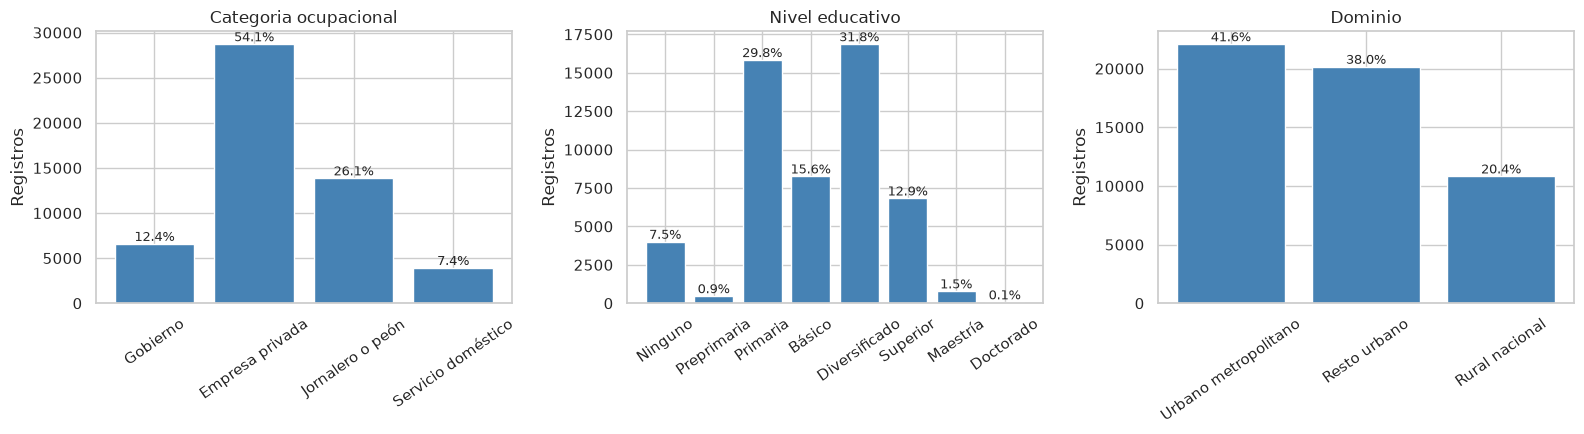

,registros,pct
categoria_ocupacional,,
Gobierno,6575,12.40
Empresa privada,28702,54.13
Jornalero o peón,13842,26.10
Servicio doméstico,3906,7.37


,registros,pct
nivel_educativo,,
Ninguno,"3,995.00",7.53
Preprimaria,459.00,0.87
Primaria,"15,822.00",29.84
Básico,"8,249.00",15.56
Diversificado,"16,851.00",31.78
Superior,"6,818.00",12.86
Maestría,771.00,1.45
Doctorado,60.00,0.11


,registros,pct
dominio,,
Urbano metropolitano,"22,072.00",41.63
Resto urbano,"20,146.00",37.99
Rural nacional,"10,807.00",20.38


In [16]:
def conteo_categoria(df, col, orden):
    pdf = df.groupBy(col).count().toPandas().set_index(col).reindex(orden).dropna()
    pdf["pct"] = 100 * pdf["count"] / pdf["count"].sum()
    return pdf


distribuciones = {
    "categoria_ocupacional": conteo_categoria(df_2025, "categoria_ocupacional", ORDEN_CATEGORIA),
    "nivel_educativo": conteo_categoria(df_2025, "nivel_educativo", ORDEN_EDUCACION),
    "dominio": conteo_categoria(df_2025, "dominio", ORDEN_DOMINIO),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, pdf) in zip(axes, distribuciones.items()):
    ax.bar(pdf.index, pdf["count"], color="steelblue")
    for i, (v, pct) in enumerate(zip(pdf["count"], pdf["pct"])):
        ax.text(i, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(col.replace("_", " ").capitalize())
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
guardar(fig, "01_distribucion_categorias")
plt.show()
for col, pdf in distribuciones.items():
    display(pdf.rename(columns={"count": "registros"}))

- Categoría: empresa privada concentra 54.1 %. Siguen jornalero o peón (26.1 %), gobierno (12.4 %) y
  servicio doméstico (7.4 %).
- Educación: diversificado (31.8 %) y primaria (29.8 %) son los niveles más comunes. Básico 15.6 %,
  superior 12.9 % y ninguno 7.5 %. Maestría y doctorado suman 1.6 %. Ningún registro quedó como `DESCONOCIDO`.
- Dominio: urbano metropolitano 41.6 %, resto urbano 38.0 % y rural nacional 20.4 %.

Son conteos de la muestra, sin ponderar.

### Forma de la distribución del salario
El histograma usa una muestra de 5,000 registros. Las líneas de media y mediana vienen del total.
El panel derecho usa escala logarítmica en el eje x solo para visualizar.

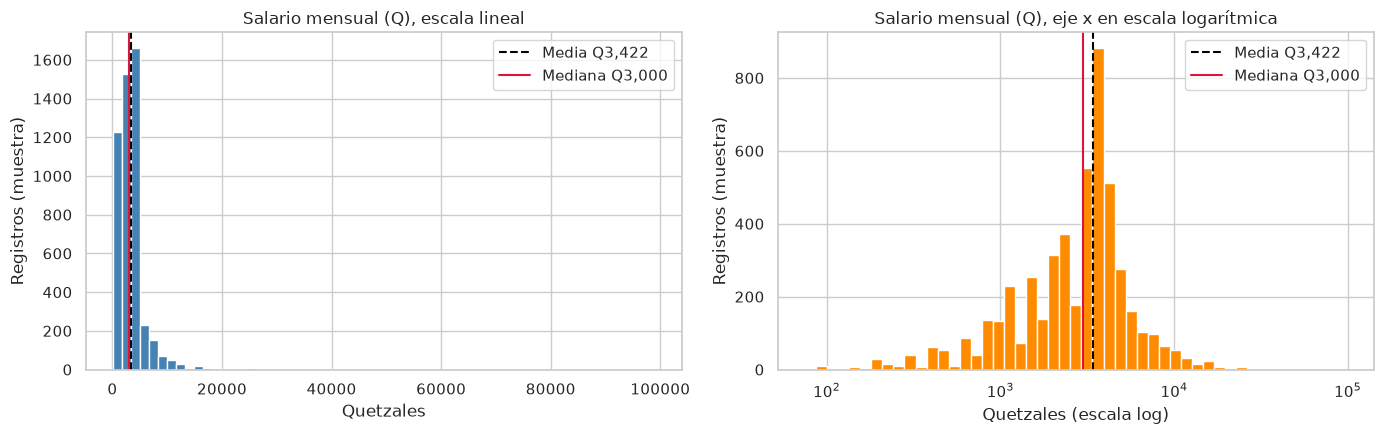

In [17]:
_n_2025 = df_2025.count()
muestra_salario = (
    df_2025.select("salario_mensual").sample(fraction=min(1.0, 6000 / _n_2025), seed=SEED).limit(5000).toPandas()
)
_media, _mediana = resumen_2025.loc["salario_mensual", ["media", "mediana"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(muestra_salario["salario_mensual"], bins=60, color="steelblue")
axes[0].set_title("Salario mensual (Q), escala lineal")
axes[0].set_xlabel("Quetzales")
_bins = np.logspace(np.log10(muestra_salario["salario_mensual"].min()), np.log10(muestra_salario["salario_mensual"].max()), 50)
axes[1].hist(muestra_salario["salario_mensual"], bins=_bins, color="darkorange")
axes[1].set_xscale("log")
axes[1].set_title("Salario mensual (Q), eje x en escala logarítmica")
axes[1].set_xlabel("Quetzales (escala log)")
for ax in axes:
    ax.axvline(_media, color="black", linestyle="--", label=f"Media Q{_media:,.0f}")
    ax.axvline(_mediana, color="crimson", linestyle="-", label=f"Mediana Q{_mediana:,.0f}")
    ax.set_ylabel("Registros (muestra)")
    ax.legend()
plt.tight_layout()
guardar(fig, "02_distribucion_salario")
plt.show()

La distribución es asimétrica a la derecha. En escala lineal casi todo se acumula por debajo de Q6,000 y
la cola llega a Q99,000. En escala logarítmica la forma se parece más a una campana.

La media (Q3,422) es Q422 mayor que la mediana (Q3,000). Los salarios altos jalan la media hacia arriba.
La mediana describe mejor al asalariado típico.

### Salario mediano por nivel educativo y categoría ocupacional

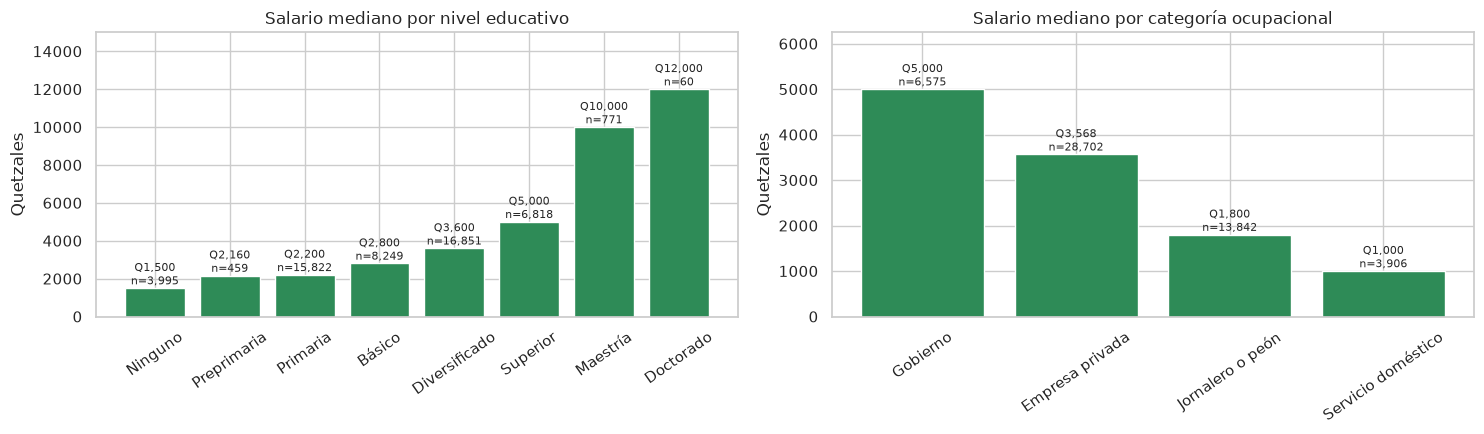

,n,mediana,media
nivel_educativo,,,
Ninguno,"3,995.00","1,500.00","1,767.09"
Preprimaria,459.00,"2,160.00","2,241.90"
Primaria,"15,822.00","2,200.00","2,307.96"
Básico,"8,249.00","2,800.00","2,730.20"
Diversificado,"16,851.00","3,600.00","3,796.41"
Superior,"6,818.00","5,000.00","5,965.30"
Maestría,771.00,"10,000.00","11,409.27"
Doctorado,60.00,"12,000.00","14,452.27"


,n,mediana,media
categoria_ocupacional,,,
Gobierno,6575,"5,000.00","5,971.53"
Empresa privada,28702,"3,567.50","3,875.14"
Jornalero o peón,13842,"1,800.00","1,878.61"
Servicio doméstico,3906,"1,000.00","1,265.74"


In [18]:
def mediana_por(df, col, orden):
    pdf = (df.groupBy(col).agg(F.count("*").alias("n"), F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                                F.mean("salario_mensual").alias("media"))
           .toPandas().set_index(col).reindex(orden).dropna())
    return pdf


medianas_educacion = mediana_por(df_2025, "nivel_educativo", ORDEN_EDUCACION)
medianas_categoria = mediana_por(df_2025, "categoria_ocupacional", ORDEN_CATEGORIA)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, pdf, titulo in [(axes[0], medianas_educacion, "nivel educativo"), (axes[1], medianas_categoria, "categoría ocupacional")]:
    ax.bar(pdf.index, pdf["mediana"], color="seagreen")
    for i, (v, n) in enumerate(zip(pdf["mediana"], pdf["n"])):
        ax.text(i, v, f"Q{v:,.0f}\nn={int(n):,}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"Salario mediano por {titulo}")
    ax.set_ylabel("Quetzales")
    ax.set_ylim(0, pdf["mediana"].max() * 1.25)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
guardar(fig, "03_mediana_educacion_categoria")
plt.show()
display(medianas_educacion)
display(medianas_categoria)

La mediana sube con el nivel educativo: Q1,500 sin educación, Q2,200 con primaria, Q3,600 con
diversificado, Q5,000 con superior y Q10,000 con maestría. Doctorado llega a Q12,000, pero con solo 60 registros.

Por categoría, gobierno tiene la mediana más alta (Q5,000). Siguen empresa privada (Q3,568), jornalero o
peón (Q1,800) y servicio doméstico (Q1,000).

Son asociaciones. No prueban que la educación o la categoría causen el salario.

### Tamaño de muestra y salario mediano por trimestre

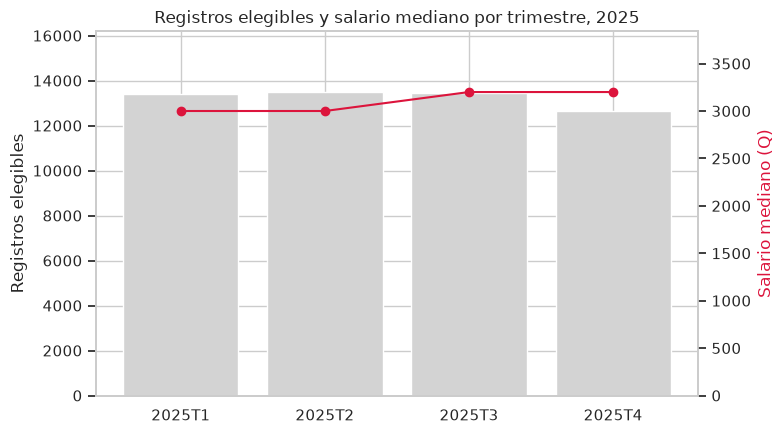

,n,mediana,media
periodo_archivo,,,
2025T1,13419,"3,000.00","3,315.63"
2025T2,13492,"3,000.00","3,364.57"
2025T3,13450,"3,200.00","3,469.07"
2025T4,12664,"3,200.00","3,544.57"


In [19]:
trimestres = (
    df_2025.groupBy("periodo_archivo")
    .agg(F.count("*").alias("n"), F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
         F.mean("salario_mensual").alias("media"))
    .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo")
)
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(trimestres.index, trimestres["n"], color="lightgray")
ax1.set_ylabel("Registros elegibles")
ax1.set_ylim(0, trimestres["n"].max() * 1.2)
ax2 = ax1.twinx()
ax2.plot(trimestres.index, trimestres["mediana"], color="crimson", marker="o")
ax2.set_ylabel("Salario mediano (Q)", color="crimson")
ax2.set_ylim(0, trimestres["mediana"].max() * 1.2)
ax2.grid(False)
ax1.set_title("Registros elegibles y salario mediano por trimestre, 2025")
plt.tight_layout()
guardar(fig, "04_trimestres")
plt.show()
display(trimestres)

La muestra analítica es estable: entre 12,664 (T4) y 13,492 (T2) registros. La mediana pasa de Q3,000 en
T1 y T2 a Q3,200 en T3 y T4. La media sube de Q3,316 a Q3,545. El cambio es pequeño y no ponderado. No
basta para afirmar un aumento en la población.

## 3. Relaciones entre variables numéricas
Correlación de Pearson con `VectorAssembler` y `Correlation.corr()` sobre todos los registros elegibles de 2025.

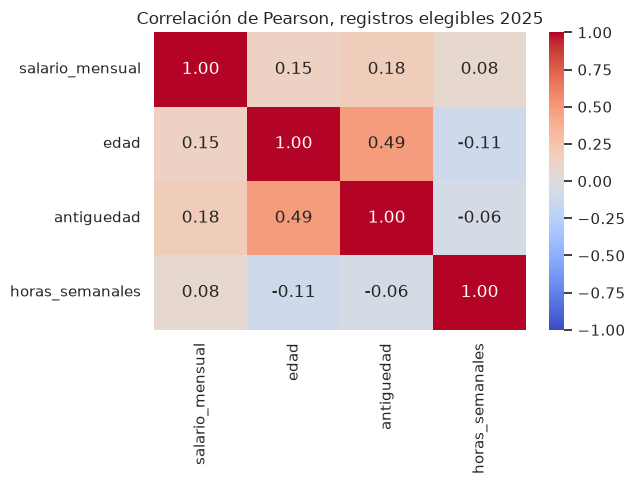

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.00,0.15,0.18,0.08
edad,0.15,1.00,0.49,-0.11
antiguedad,0.18,0.49,1.00,-0.06
horas_semanales,0.08,-0.11,-0.06,1.00


In [20]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

_vec = VectorAssembler(inputCols=NUMERIC_VARS, outputCol="vars_corr").transform(df_2025).select("vars_corr")
corr_pdf = pd.DataFrame(Correlation.corr(_vec, "vars_corr", "pearson").head()[0].toArray(),
                        index=NUMERIC_VARS, columns=NUMERIC_VARS)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr_pdf, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Pearson, registros elegibles 2025")
plt.tight_layout()
guardar(fig, "05_correlaciones")
plt.show()
display(corr_pdf)

- Ninguna variable tiene una asociación lineal fuerte con el salario. La mayor es la antigüedad
  (r = 0.18), luego la edad (0.15) y las horas (0.08). El salario es muy asimétrico y depende más de las
  variables categóricas.
- Edad y antigüedad tienen una relación positiva moderada (r = 0.49). Para acumular antigüedad hay que
  tener edad. No llega a 1 porque muchas personas mayores cambiaron de trabajo hace poco.
- Las horas tienen una relación negativa débil con la edad (r = −0.11).

Correlación no implica causalidad.

## 4. Segmentación de perfiles con KMeans

Variables base: edad, antigüedad y horas habituales. Se prueba también agregar el salario para decidir
si vale la pena. Las variables se estandarizan con `StandardScaler` (media 0, desviación 1) dentro de
un `Pipeline`. Se evalúa K = 2, 3, 4 y 5 con la silueta y la suma de distancias al centroide (WSSSE).

,variante,k,silueta,wssse,cluster_menor_pct
0,sin salario,2,0.55,"106,717.39",27.51
1,sin salario,3,0.44,"84,468.15",13.54
2,sin salario,4,0.47,"64,437.03",12.91
3,sin salario,5,0.49,"56,848.45",4.93
4,con salario,2,0.51,"157,345.56",27.00
5,con salario,3,0.36,"133,746.95",20.47
6,con salario,4,0.37,"113,556.65",14.25
7,con salario,5,0.41,"94,475.72",3.97


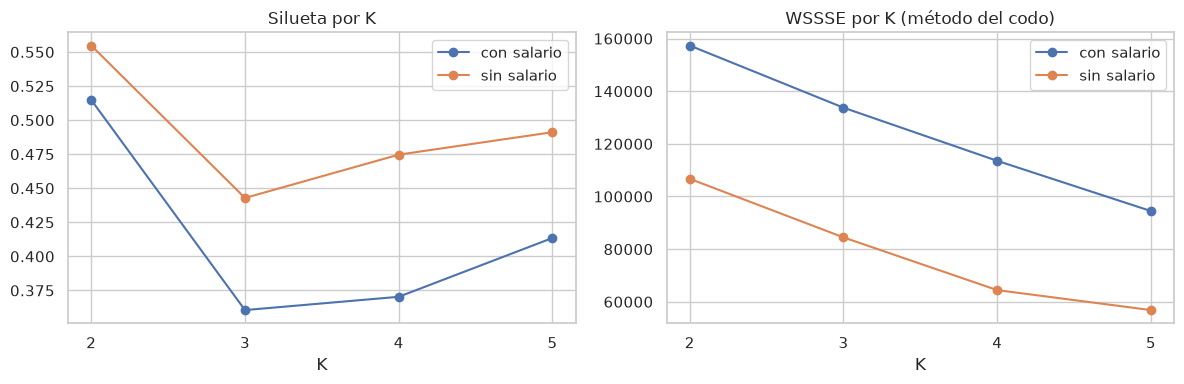

In [21]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

VARS_CLUSTER = ["edad", "antiguedad", "horas_semanales"]
VARIANTES = {"sin salario": VARS_CLUSTER, "con salario": VARS_CLUSTER + ["salario_mensual"]}


def pipeline_kmeans(cols, k):
    return Pipeline(stages=[
        VectorAssembler(inputCols=cols, outputCol="vars_cluster"),
        StandardScaler(inputCol="vars_cluster", outputCol="features_cluster", withMean=True, withStd=True),
        KMeans(k=k, seed=SEED, featuresCol="features_cluster", predictionCol="cluster", maxIter=50),
    ])


evaluador_silueta = ClusteringEvaluator(featuresCol="features_cluster", predictionCol="cluster")
filas_k, modelos_k = [], {}
for variante, cols in VARIANTES.items():
    for k in [2, 3, 4, 5]:
        modelo = pipeline_kmeans(cols, k).fit(df_2025)
        pred = modelo.transform(df_2025)
        tamanos = modelo.stages[-1].summary.clusterSizes
        filas_k.append(dict(variante=variante, k=k, silueta=evaluador_silueta.evaluate(pred),
                            wssse=modelo.stages[-1].summary.trainingCost,
                            cluster_menor_pct=100 * min(tamanos) / _n_2025))
        modelos_k[(variante, k)] = modelo

eval_k = pd.DataFrame(filas_k)
display(eval_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for variante, pdf in eval_k.groupby("variante"):
    axes[0].plot(pdf["k"], pdf["silueta"], marker="o", label=variante)
    axes[1].plot(pdf["k"], pdf["wssse"], marker="o", label=variante)
axes[0].set_title("Silueta por K")
axes[1].set_title("WSSSE por K (método del codo)")
for ax in axes:
    ax.set_xlabel("K")
    ax.set_xticks([2, 3, 4, 5])
    ax.legend()
plt.tight_layout()
guardar(fig, "06_kmeans_seleccion_k")
plt.show()

**Salario sí o no.** Con salario la silueta baja en todos los K (0.51 contra 0.55 con K = 2; 0.37
contra 0.47 con K = 4). El salario es muy asimétrico y, aun estandarizado, sus extremos arrastran los
centroides. Además, se busca un perfil laboral para luego comparar salarios entre perfiles. Por eso el
salario queda fuera del clustering y solo se usa para describir los grupos.

**Elección de K.** K = 2 tiene la mayor silueta (0.55), pero solo separa jóvenes de mayores. Nuestro
criterio fue combinar el codo del WSSSE, la silueta y que ningún cluster tenga menos del 10 % de los
registros. El WSSSE cae 21 % de 2 a 3, 24 % de 3 a 4 y solo 12 % de 4 a 5. K = 5 deja un cluster de 4.9 %.
Se elige K = 4: silueta 0.47 y cluster menor de 12.9 %.

In [22]:
VARIANTE_ELEGIDA = "sin salario"
K_ELEGIDO = 4

modelo_kmeans = modelos_k[(VARIANTE_ELEGIDA, K_ELEGIDO)]
df_clusters = modelo_kmeans.transform(df_2025).drop("vars_cluster", "features_cluster").cache()

perfil = (
    df_clusters.groupBy("cluster").agg(
        F.count("*").alias("n"),
        F.mean("edad").alias("edad_media"),
        F.mean("antiguedad").alias("antiguedad_media"),
        F.mean("horas_semanales").alias("horas_media"),
        F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
        F.mean("salario_mensual").alias("salario_medio"),
        F.mean((F.col("categoria_ocupacional") == "Gobierno").cast("int")).alias("pct_gobierno"),
        F.mean((F.col("categoria_ocupacional") == "Empresa privada").cast("int")).alias("pct_privada"),
        F.mean((F.col("categoria_ocupacional") == "Jornalero o peón").cast("int")).alias("pct_jornalero"),
        F.mean((F.col("categoria_ocupacional") == "Servicio doméstico").cast("int")).alias("pct_domestico"),
        F.mean((F.col("dominio") == "Rural nacional").cast("int")).alias("pct_rural"),
        F.mean(F.col("nivel_educativo").isin("Diversificado", "Superior", "Maestría", "Doctorado").cast("int")).alias("pct_diversificado_o_mas"),
    ).orderBy("cluster").toPandas().set_index("cluster")
)
perfil["pct_registros"] = 100 * perfil["n"] / perfil["n"].sum()
for c in [c for c in perfil.columns if c.startswith("pct_") and c != "pct_registros"]:
    perfil[c] = 100 * perfil[c]
display(perfil.T)

cluster,0,1,2,3
n,"24,400.00","9,255.00","12,524.00","6,846.00"
edad_media,26.00,30.13,48.80,49.87
antiguedad_media,2.44,3.41,4.09,22.27
horas_media,40.59,74.17,39.73,41.04
salario_mediano,"3,000.00","3,000.00","3,000.00","3,800.00"
salario_medio,"3,083.16","3,223.81","3,537.78","4,683.35"
pct_gobierno,8.02,7.70,14.02,31.38
pct_privada,56.84,67.42,46.54,40.37
pct_jornalero,29.23,19.04,27.28,22.36
pct_domestico,5.90,5.83,12.16,5.89


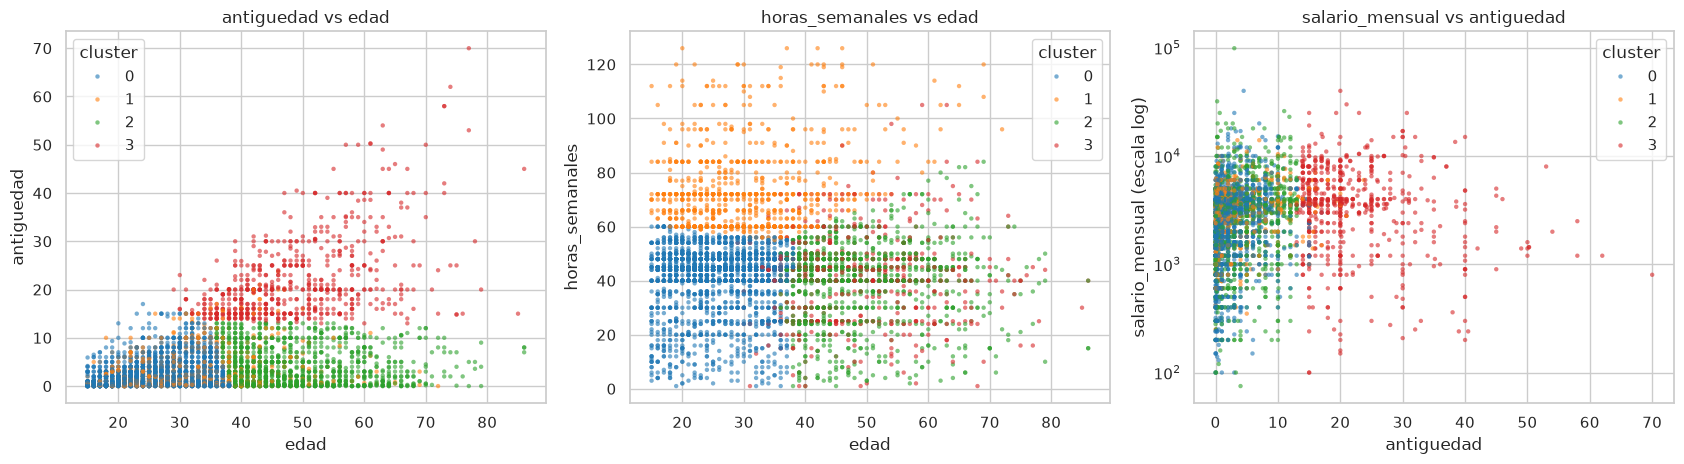

In [23]:
muestra_clusters = (
    df_clusters.select("edad", "antiguedad", "horas_semanales", "salario_mensual", "cluster")
    .sample(fraction=min(1.0, 6000 / _n_2025), seed=SEED).limit(5000).toPandas()
)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
_paleta = sns.color_palette("tab10", K_ELEGIDO)
for ax, (x, y) in zip(axes, [("edad", "antiguedad"), ("edad", "horas_semanales"), ("antiguedad", "salario_mensual")]):
    sns.scatterplot(data=muestra_clusters, x=x, y=y, hue="cluster", palette=_paleta, s=10, alpha=0.6, ax=ax, linewidth=0)
    ax.set_title(f"{y} vs {x}")
axes[2].set_yscale("log")
axes[2].set_ylabel("salario_mensual (escala log)")
plt.tight_layout()
guardar(fig, "07_kmeans_perfiles")
plt.show()

| Cluster | Registros | Perfil |
|---|---|---|
| 0 | 46.0 % | **Jóvenes que empiezan.** 26 años, 2.4 años de antigüedad y 41 horas. 52 % con diversificado o más. Mediana Q3,000. |
| 1 | 17.5 % | **Jornada extendida.** 30 años, 3.4 años de antigüedad y 74 horas por semana. 67 % en empresa privada. Mediana Q3,000. |
| 2 | 23.6 % | **Adultos con poca antigüedad.** 49 años pero solo 4.1 años en su trabajo y 40 horas. Más servicio doméstico (12 %). Mediana Q3,000. |
| 3 | 12.9 % | **Trayectoria estable.** 50 años, 22 años de antigüedad y 41 horas. 31 % en gobierno. Mediana Q3,800 y media Q4,683. |

Los grupos se separan por edad, antigüedad y jornada, no por salario. La mediana es Q3,000 en tres de
los cuatro perfiles. Solo el de trayectoria estable gana claramente más, y ahí pesa el empleo público.
Esto concuerda con las correlaciones bajas de la sección 3. Los perfiles describen la muestra, no la
población, y el cluster no se usa como predictor.

---
# Modelado supervisado

Objetivo: `salario_mensual` en quetzales, sin transformar. Predictores: edad, antigüedad, horas
semanales, nivel educativo, categoría ocupacional y dominio.

- Entrenamiento de desarrollo: 2025 T1–T3.
- Validación: 2025 T4. Se elige la configuración con menor RMSE de validación.
- Entrenamiento final: todo 2025 con la configuración elegida.
- Prueba final: 2026 T1.

Todas las etapas del pipeline se ajustan solo con los datos de entrenamiento. Las métricas no se ponderan.

In [24]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

TARGET = "salario_mensual"
NUM_FEATS = ["edad", "antiguedad", "horas_semanales"]
CAT_FEATS = ["nivel_educativo", "categoria_ocupacional", "dominio"]

train = df_2025.filter(F.col("trimestre_calendario").isin(1, 2, 3)).select(TARGET, *NUM_FEATS, *CAT_FEATS).cache()
valid = df_2025.filter(F.col("trimestre_calendario") == 4).select(TARGET, *NUM_FEATS, *CAT_FEATS).cache()
print(f"Entrenamiento (2025 T1-T3): {train.count():,} | Validación (2025 T4): {valid.count():,}")


def etapas_preparacion():
    indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CAT_FEATS]
    encoder = OneHotEncoder(inputCols=[f"{c}_idx" for c in CAT_FEATS], outputCols=[f"{c}_ohe" for c in CAT_FEATS])
    assembler = VectorAssembler(inputCols=NUM_FEATS + [f"{c}_ohe" for c in CAT_FEATS], outputCol="features")
    return indexers + [encoder, assembler]


def metricas(pred, pred_col="prediction"):
    ev = RegressionEvaluator(labelCol=TARGET, predictionCol=pred_col)
    return {m.upper() if m != "r2" else "R2": ev.evaluate(pred, {ev.metricName: m}) for m in ["mae", "rmse", "r2"]}


def nombres_features(df_transformado):
    attrs = df_transformado.schema["features"].metadata["ml_attr"]["attrs"]
    return [a["name"] for a in sorted(sum(attrs.values(), []), key=lambda a: a["idx"])]

Entrenamiento (2025 T1-T3): 40,361 | Validación (2025 T4): 12,664


## 5. Regresión lineal

Modelo de referencia: predecir siempre la media del salario de entrenamiento.

In [25]:
media_train = train.agg(F.mean(TARGET)).first()[0]
metricas_baseline_val = metricas(valid.withColumn("prediction", F.lit(media_train)))
print(f"Media de entrenamiento: Q{media_train:,.2f}")
display(pd.DataFrame([metricas_baseline_val], index=["referencia (media)"]))

Media de entrenamiento: Q3,383.12


,MAE,RMSE,R2
referencia (media),"1,672.50","2,889.57",-0.00


Pipeline: `StringIndexer` + `OneHotEncoder` para las categóricas, `VectorAssembler` y
`LinearRegression` con `standardization=True` (estandarización interna, sin `StandardScaler`).
Se prueban ocho configuraciones de regularización.

In [26]:
CONFIG_LR = [
    dict(regParam=0.0, elasticNetParam=0.0),
    dict(regParam=0.01, elasticNetParam=0.0),
    dict(regParam=0.1, elasticNetParam=0.0),
    dict(regParam=1.0, elasticNetParam=0.0),
    dict(regParam=0.01, elasticNetParam=1.0),
    dict(regParam=0.1, elasticNetParam=1.0),
    dict(regParam=1.0, elasticNetParam=1.0),
    dict(regParam=0.1, elasticNetParam=0.5),
]


def pipeline_lr(regParam, elasticNetParam):
    lr = LinearRegression(featuresCol="features", labelCol=TARGET, regParam=regParam,
                          elasticNetParam=elasticNetParam, standardization=True, maxIter=200)
    return Pipeline(stages=etapas_preparacion() + [lr])


filas_lr, modelos_lr = [], []
for cfg in CONFIG_LR:
    modelo = pipeline_lr(**cfg).fit(train)
    filas_lr.append(dict(**cfg, **metricas(modelo.transform(valid))))
    modelos_lr.append(modelo)

resultados_lr = pd.DataFrame(filas_lr)
display(resultados_lr)

mejor_lr_idx = int(resultados_lr["RMSE"].idxmin())
MEJOR_CONFIG_LR = CONFIG_LR[mejor_lr_idx]
mejor_lr = modelos_lr[mejor_lr_idx]
mejor_lr.write().overwrite().save(str(MODELS_DIR / "lr_best"))
metricas_lr_val = metricas(mejor_lr.transform(valid))
print("Mejor configuración LR:", MEJOR_CONFIG_LR, "-> guardada en models/lr_best")

,regParam,elasticNetParam,MAE,RMSE,R2
0,0.00,0.00,"1,210.14","2,186.42",0.43
1,0.01,0.00,"1,210.14","2,186.42",0.43
2,0.10,0.00,"1,210.13","2,186.42",0.43
3,1.00,0.00,"1,210.09","2,186.43",0.43
4,0.01,1.00,"1,210.13","2,186.42",0.43
5,0.10,1.00,"1,210.09","2,186.43",0.43
6,1.00,1.00,"1,209.70","2,186.50",0.43
7,0.10,0.50,"1,210.11","2,186.42",0.43


Mejor configuración LR: {'regParam': 0.0, 'elasticNetParam': 0.0} -> guardada en models/lr_best


In [27]:
_coef = pd.DataFrame({
    "variable": nombres_features(mejor_lr.transform(valid.limit(1))),
    "coeficiente": mejor_lr.stages[-1].coefficients.toArray(),
})
print(f"Intercepto: {mejor_lr.stages[-1].intercept:,.2f}")
display(_coef)
display(pd.DataFrame([metricas_baseline_val, metricas_lr_val], index=["referencia (media)", "regresión lineal"]))

Intercepto: 1,775.50


,variable,coeficiente
0,edad,20.43
1,antiguedad,23.37
2,horas_semanales,16.17
3,nivel_educativo_ohe_Diversificado,82.49
4,nivel_educativo_ohe_Primaria,-753.93
5,nivel_educativo_ohe_Básico,-548.72
6,nivel_educativo_ohe_Superior,"1,776.89"
7,nivel_educativo_ohe_Ninguno,"-1,250.90"
8,nivel_educativo_ohe_Maestría,"6,863.06"
9,nivel_educativo_ohe_Preprimaria,-966.57


,MAE,RMSE,R2
referencia (media),"1,672.50","2,889.57",-0.00
regresión lineal,"1,210.14","2,186.42",0.43


- La regresión lineal baja el MAE de Q1,673 a Q1,210 y el RMSE de Q2,890 a Q2,186 frente a la
  referencia. Explica 43 % de la varianza del salario en validación (R² = 0.43). La referencia tiene R² ≈ 0.
- Las ocho configuraciones dan casi el mismo RMSE (diferencias menores a Q0.10). Con 40 mil registros y
  pocas variables, la regularización casi no mueve los coeficientes. Gana `regParam = 0`, sin penalización.
- Los coeficientes tienen la dirección esperada. Con lo demás igual, maestría suma unos Q7,600 más que
  primaria y gobierno unos Q2,800 más que servicio doméstico. Cada año de edad suma unos Q20, cada año de
  antigüedad Q23 y cada hora semanal Q16.
- El error sigue siendo alto: el RMSE es cerca de Q2,200. Los salarios extremos pesan mucho en esa métrica.

## 6. Random Forest

Mismos conjuntos y mismas etapas de preparación. `RandomForestRegressor` no necesita estandarización.
Se varían la cantidad de árboles y la profundidad máxima. Semilla fija.

In [28]:
CONFIG_RF = [
    dict(numTrees=50, maxDepth=5),
    dict(numTrees=100, maxDepth=5),
    dict(numTrees=50, maxDepth=10),
    dict(numTrees=100, maxDepth=10),
]


def pipeline_rf(numTrees, maxDepth):
    rf = RandomForestRegressor(featuresCol="features", labelCol=TARGET, numTrees=numTrees, maxDepth=maxDepth, seed=SEED)
    return Pipeline(stages=etapas_preparacion() + [rf])


filas_rf, modelos_rf = [], []
for cfg in CONFIG_RF:
    modelo = pipeline_rf(**cfg).fit(train)
    filas_rf.append(dict(**cfg, **metricas(modelo.transform(valid)),
                         RMSE_entrenamiento=metricas(modelo.transform(train))["RMSE"]))
    modelos_rf.append(modelo)

resultados_rf = pd.DataFrame(filas_rf)
display(resultados_rf)

mejor_rf_idx = int(resultados_rf["RMSE"].idxmin())
MEJOR_CONFIG_RF = CONFIG_RF[mejor_rf_idx]
mejor_rf = modelos_rf[mejor_rf_idx]
mejor_rf.write().overwrite().save(str(MODELS_DIR / "rf_best"))
metricas_rf_val = metricas(mejor_rf.transform(valid))
print("Mejor configuración RF:", MEJOR_CONFIG_RF, "-> guardada en models/rf_best")

,numTrees,maxDepth,MAE,RMSE,R2,RMSE_entrenamiento
0,50,5,"1,150.16","2,159.75",0.44,"2,199.78"
1,100,5,"1,164.85","2,161.70",0.44,"2,202.18"
2,50,10,"1,076.08","1,968.66",0.53,"1,942.87"
3,100,10,"1,076.05","1,970.79",0.53,"1,933.93"


Mejor configuración RF: {'numTrees': 50, 'maxDepth': 10} -> guardada en models/rf_best


In [29]:
_imp = pd.DataFrame({
    "variable": nombres_features(mejor_rf.transform(valid.limit(1))),
    "importancia": mejor_rf.stages[-1].featureImportances.toArray(),
}).sort_values("importancia", ascending=False)
display(_imp)

comparacion_val = pd.DataFrame([metricas_baseline_val, metricas_lr_val, metricas_rf_val],
                               index=["referencia (media)", "regresión lineal", "random forest"])
display(comparacion_val)

,variable,importancia
8,nivel_educativo_ohe_Maestría,0.18
6,nivel_educativo_ohe_Superior,0.12
13,categoria_ocupacional_ohe_Gobierno,0.11
2,horas_semanales,0.10
0,edad,0.10
12,categoria_ocupacional_ohe_Jornalero o peón,0.08
1,antiguedad,0.08
11,categoria_ocupacional_ohe_Empresa privada,0.07
14,categoria_ocupacional_ohe_Servicio doméstico,0.04
15,dominio_ohe_Urbano metropolitano,0.03


,MAE,RMSE,R2
referencia (media),"1,672.50","2,889.57",-0.00
regresión lineal,"1,210.14","2,186.42",0.43
random forest,"1,076.08","1,968.66",0.53


- La profundidad importa más que el número de árboles. Con profundidad 5 el RMSE es cerca de Q2,160;
  con profundidad 10 baja a Q1,969. Pasar de 50 a 100 árboles no mejora.
- Gana 50 árboles con profundidad 10: MAE Q1,076, RMSE Q1,969 y R² = 0.53. El RMSE de entrenamiento
  (Q1,943) es parecido al de validación, así que no hay sobreajuste fuerte.
- Random forest supera a la regresión lineal en las tres métricas (RMSE Q218 menor, R² 0.53 contra 0.43)
  y a la referencia.
- La regresión lineal suma efectos fijos. El bosque capta relaciones no lineales e interacciones. Por
  ejemplo, que el salario crezca más rápido en los niveles educativos altos o que la antigüedad pese
  distinto según la categoría. Las variables más importantes son maestría, superior, gobierno, horas y edad.

## 7. Entrenamiento final y evaluación en 2026

Cada algoritmo se reentrena con todo 2025 usando su configuración elegida. La prueba usa 2026 T1,
preparado con las mismas reglas de la sección 1. Los dos modelos se evalúan sobre los mismos registros.

In [30]:
train_final = df_2025.select(TARGET, *NUM_FEATS, *CAT_FEATS).cache()
test = (
    df_2026.withColumn("id_registro", F.concat_ws("-", *CLAVE))
    .select("id_registro", TARGET, *NUM_FEATS, *CAT_FEATS).cache()
)

lr_final = pipeline_lr(**MEJOR_CONFIG_LR).fit(train_final)
rf_final = pipeline_rf(**MEJOR_CONFIG_RF).fit(train_final)
lr_final.write().overwrite().save(str(MODELS_DIR / "lr_final"))
rf_final.write().overwrite().save(str(MODELS_DIR / "rf_final"))
media_train_final = train_final.agg(F.mean(TARGET)).first()[0]

pred_test = (
    lr_final.transform(test).select("id_registro", TARGET, *CAT_FEATS, F.col("prediction").alias("pred_lr"))
    .join(rf_final.transform(test).select("id_registro", F.col("prediction").alias("pred_rf")), "id_registro", "inner")
    .withColumn("pred_referencia", F.lit(media_train_final))
    .withColumn("residuo_lr", F.col(TARGET) - F.col("pred_lr"))
    .withColumn("residuo_rf", F.col(TARGET) - F.col("pred_rf"))
    .cache()
)
n_test, n_pred = test.count(), pred_test.count()
print(f"Registros elegibles 2026 T1: {n_test:,} | con predicción de ambos modelos: {n_pred:,}")
assert n_test == n_pred, "LR y RF no se evaluaron sobre los mismos registros"

metricas_test = {
    "referencia (media)": metricas(pred_test, "pred_referencia"),
    "regresión lineal": metricas(pred_test, "pred_lr"),
    "random forest": metricas(pred_test, "pred_rf"),
}
comparacion_final = pd.concat(
    {"validación 2025 T4": comparacion_val, "prueba 2026 T1": pd.DataFrame(metricas_test).T}, axis=1
)
display(comparacion_final)

Registros elegibles 2026 T1: 13,258 | con predicción de ambos modelos: 13,258


validación 2025 T4                prueba 2026 T1           \
                                  MAE     RMSE    R2            MAE     RMSE   
referencia (media)           1,672.50 2,889.57 -0.00       1,718.09 2,871.42   
regresión lineal             1,210.14 2,186.42  0.43       1,240.71 2,163.75   
random forest                1,076.08 1,968.66  0.53       1,104.48 1,958.33   

                          
                      R2  
referencia (media) -0.00  
regresión lineal    0.43  
random forest       0.53

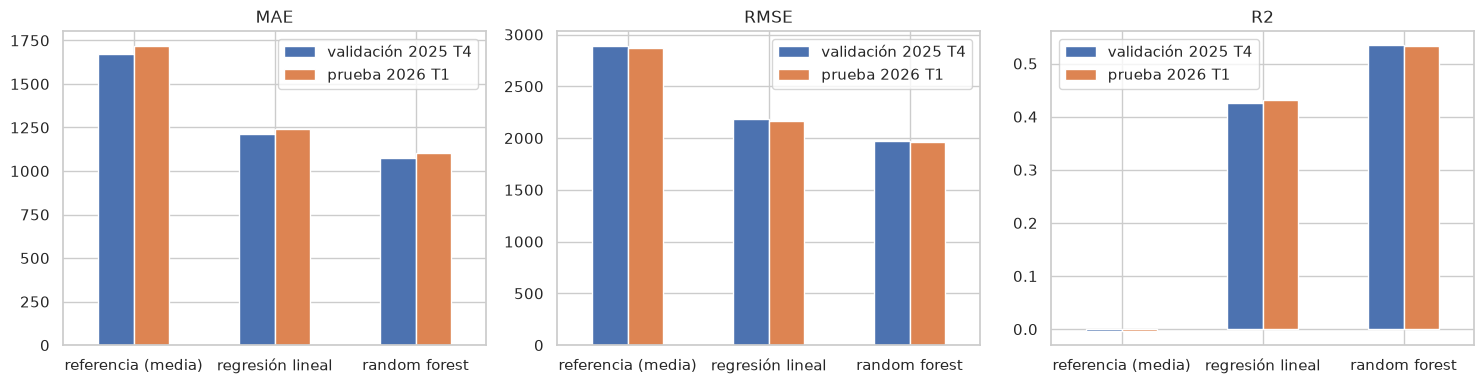

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ["MAE", "RMSE", "R2"]):
    comparacion_final.xs(m, axis=1, level=1).plot.bar(ax=ax, rot=0)
    ax.set_title(m)
    ax.set_xlabel("")
plt.tight_layout()
guardar(fig, "08_metricas_modelos")
plt.show()

- Los modelos finales se entrenaron con los 53,025 registros de 2025. Ambos se evaluaron sobre los mismos
  13,258 registros de 2026 T1.
- Random forest vuelve a ganar: MAE Q1,104, RMSE Q1,958 y R² = 0.53. La regresión lineal queda en MAE
  Q1,241, RMSE Q2,164 y R² = 0.43. La referencia tiene MAE Q1,718 y RMSE Q2,871.
- Las métricas de prueba son casi iguales a las de validación. Los modelos funcionan en un período nuevo
  sin perder desempeño.
- Aun así, el mejor modelo explica cerca de la mitad de la variación del salario. Con seis variables no se
  captura la ocupación, la rama de actividad ni el tamaño de la empresa.

## 8. Visualización y análisis de errores

Residuo = salario real − salario predicho. Positivo: el modelo subestima. Negativo: sobreestima.
Las gráficas usan la misma muestra de 5,000 registros de 2026 T1 para ambos modelos. Las tablas por
grupo usan todos los registros de prueba.

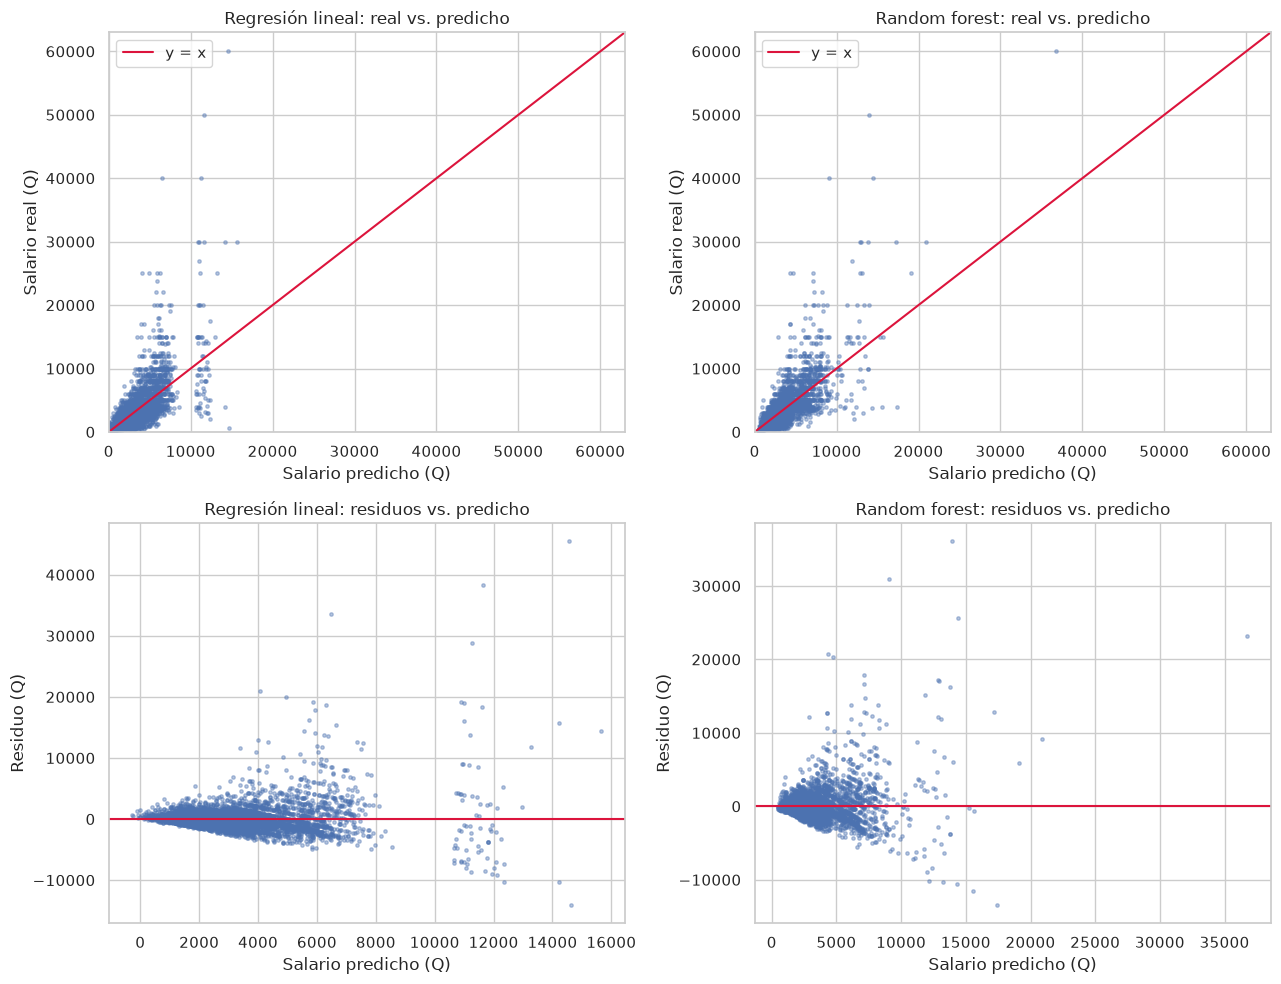

In [32]:
muestra_test = pred_test.sample(fraction=min(1.0, 6000 / n_test), seed=SEED).limit(5000).toPandas()
_lim = max(muestra_test[TARGET].max(), muestra_test[["pred_lr", "pred_rf"]].max().max()) * 1.05

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for j, (modelo, col) in enumerate([("Regresión lineal", "lr"), ("Random forest", "rf")]):
    ax = axes[0, j]
    ax.scatter(muestra_test[f"pred_{col}"], muestra_test[TARGET], s=6, alpha=0.4)
    ax.plot([0, _lim], [0, _lim], color="crimson", label="y = x")
    ax.set_xlim(0, _lim)
    ax.set_ylim(0, _lim)
    ax.set_xlabel("Salario predicho (Q)")
    ax.set_ylabel("Salario real (Q)")
    ax.set_title(f"{modelo}: real vs. predicho")
    ax.legend()
    ax = axes[1, j]
    ax.scatter(muestra_test[f"pred_{col}"], muestra_test[f"residuo_{col}"], s=6, alpha=0.4)
    ax.axhline(0, color="crimson")
    ax.set_xlabel("Salario predicho (Q)")
    ax.set_ylabel("Residuo (Q)")
    ax.set_title(f"{modelo}: residuos vs. predicho")
plt.tight_layout()
guardar(fig, "09_real_predicho_residuos")
plt.show()

### MAE y error medio por grupo (todos los registros de prueba)

In [33]:
def errores_por(col, orden):
    return (
        pred_test.groupBy(col).agg(
            F.count("*").alias("n"),
            F.mean(TARGET).alias("salario_medio"),
            F.mean(F.abs("residuo_lr")).alias("MAE_lr"),
            F.mean("residuo_lr").alias("error_medio_lr"),
            F.mean(F.abs("residuo_rf")).alias("MAE_rf"),
            F.mean("residuo_rf").alias("error_medio_rf"),
        ).toPandas().set_index(col).reindex(orden).dropna(how="all")
    )


errores_educacion = errores_por("nivel_educativo", ORDEN_EDUCACION)
errores_dominio = errores_por("dominio", ORDEN_DOMINIO)
display(errores_educacion)
display(errores_dominio)

,n,salario_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
nivel_educativo,,,,,,
Ninguno,"1,016.00","1,884.14",823.51,109.34,656.38,-60.78
Preprimaria,80.00,"2,374.56",735.21,88.76,636.91,-139.36
Primaria,"3,957.00","2,422.75",870.04,54.56,758.66,37.99
Básico,"2,164.00","2,905.46",894.45,127.77,819.34,125.89
Diversificado,"4,117.00","3,924.24","1,109.31",103.98,"1,019.18",127.62
Superior,"1,729.00","6,264.36","2,566.37",295.51,"2,298.60",265.09
Maestría,183.00,"11,290.64","5,552.88",-131.50,"4,635.91",-276.17
Doctorado,12.00,"20,291.67","12,919.31","6,062.70","10,975.59","6,410.08"


,n,salario_medio,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
dominio,,,,,,
Urbano metropolitano,"5,632.00","4,352.31","1,446.09",136.04,"1,320.69",160.16
Resto urbano,"4,846.00","3,281.64","1,189.65",134.28,"1,042.67",89.25
Rural nacional,"2,780.00","2,467.73",913.64,65.24,774.22,9.17


**Gráficas.** Los puntos se alejan de la línea y = x cuando sube el salario real. Los salarios reales
altos quedan muy por encima de lo predicho. Los residuos se abren en abanico: el error crece con el salario
predicho. La regresión lineal forma un grupo aparte cerca de Q11,000–12,000: son maestría y doctorado,
donde el coeficiente educativo pesa mucho. También da algunas predicciones cercanas a cero. Random forest
reparte mejor las predicciones y queda más cerca de la diagonal.

**Nivel educativo.** El MAE crece con el nivel porque también crece el salario: entre Q640 y Q900 en
ninguno, preprimaria, primaria y básico; unos Q2,300–2,570 en superior y Q4,600–5,550 en maestría. En la
mayoría de niveles el error medio es pequeño (entre −Q280 y +Q300). En doctorado los modelos subestiman
unos Q6,000, pero solo hay 12 registros. Random forest tiene menor MAE en todos los niveles.

**Dominio.** Urbano metropolitano tiene el mayor MAE (Q1,446 LR, Q1,321 RF) y rural nacional el menor
(Q914, Q774). El error medio es positivo en los tres: en 2026 los modelos subestiman un poco, más en la
zona metropolitana (+Q136 a +Q160) que en la rural (+Q9 a +Q65).

### Errores por percentil de salario
Se comparan los percentiles del salario real con los de cada predicción, y luego el error por decil
del salario real. Todo sobre los registros completos de prueba.

,real,pred_lr,pred_rf
p5,720.00,"1,095.43","1,083.51"
p10,"1,000.00","1,418.99","1,457.44"
p25,"2,000.00","2,178.10","2,228.43"
p50,"3,200.00","3,282.51","3,275.02"
p75,"4,080.00","4,211.67","4,065.22"
p90,"6,000.00","5,678.29","5,871.75"
p95,"8,000.00","6,425.77","6,938.86"
p99,"15,000.00","11,018.15","10,898.45"


,n,salario_min,salario_max,salario_medio,pred_media_lr,pred_media_rf,MAE_lr,error_medio_lr,MAE_rf,error_medio_rf
decil,,,,,,,,,,
1,1486,100.00,"1,000.00",735.43,"1,722.50","1,619.68","1,070.49",-987.07,897.61,-884.25
2,1383,"1,008.00","1,600.00","1,375.90","2,146.83","2,095.40",933.67,-770.92,825.37,-719.50
3,1163,"1,620.00","2,000.00","1,923.06","2,618.22","2,585.15",983.22,-695.16,835.46,-662.09
4,1523,"2,010.00","2,800.00","2,490.88","2,748.38","2,765.28",863.24,-257.50,696.21,-274.40
5,1192,"2,850.00","3,200.00","3,054.17","3,092.07","3,088.94",836.90,-37.90,674.77,-34.77
6,1249,"3,205.00","3,700.00","3,527.37","3,639.84","3,628.12",844.78,-112.47,721.36,-100.75
7,1876,"3,720.00","4,000.00","3,920.73","3,964.14","3,925.95",817.11,-43.41,752.45,-5.22
8,910,"4,002.00","4,500.00","4,304.50","4,175.84","4,130.27",904.94,128.66,832.39,174.23
9,1225,"4,520.00","6,000.00","5,278.97","4,578.33","4,617.32","1,369.15",700.65,"1,451.17",661.66


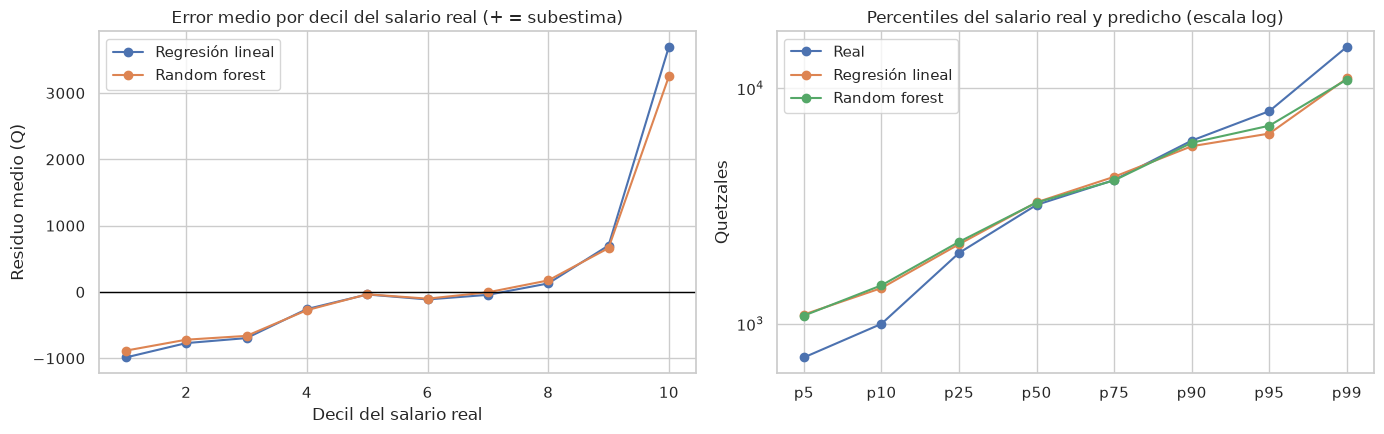

In [34]:
_q = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
_qs = "array(" + ", ".join(str(q) for q in _q) + ")"
_r = pred_test.agg(*[F.expr(f"percentile({c}, {_qs})").alias(c) for c in [TARGET, "pred_lr", "pred_rf"]]).first()
percentiles_test = pd.DataFrame({"real": _r[TARGET], "pred_lr": _r["pred_lr"], "pred_rf": _r["pred_rf"]},
                                index=[f"p{int(q * 100)}" for q in _q])
display(percentiles_test)

_cortes = pred_test.agg(F.expr(f"percentile({TARGET}, array({', '.join(str(i / 10) for i in range(1, 10))}))")).first()[0]
_decil = F.lit(10)
for i, corte in reversed(list(enumerate(_cortes, start=1))):
    _decil = F.when(F.col(TARGET) <= corte, F.lit(i)).otherwise(_decil)
errores_decil = (
    pred_test.withColumn("decil", _decil).groupBy("decil").agg(
        F.count("*").alias("n"), F.min(TARGET).alias("salario_min"), F.max(TARGET).alias("salario_max"),
        F.mean(TARGET).alias("salario_medio"), F.mean("pred_lr").alias("pred_media_lr"), F.mean("pred_rf").alias("pred_media_rf"),
        F.mean(F.abs("residuo_lr")).alias("MAE_lr"), F.mean("residuo_lr").alias("error_medio_lr"),
        F.mean(F.abs("residuo_rf")).alias("MAE_rf"), F.mean("residuo_rf").alias("error_medio_rf"),
    ).orderBy("decil").toPandas().set_index("decil")
)
display(errores_decil)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(errores_decil.index, errores_decil["error_medio_lr"], marker="o", label="Regresión lineal")
axes[0].plot(errores_decil.index, errores_decil["error_medio_rf"], marker="o", label="Random forest")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Error medio por decil del salario real (+ = subestima)")
axes[0].set_xlabel("Decil del salario real")
axes[0].set_ylabel("Residuo medio (Q)")
axes[0].legend()
axes[1].plot(percentiles_test.index, percentiles_test["real"], marker="o", label="Real")
axes[1].plot(percentiles_test.index, percentiles_test["pred_lr"], marker="o", label="Regresión lineal")
axes[1].plot(percentiles_test.index, percentiles_test["pred_rf"], marker="o", label="Random forest")
axes[1].set_yscale("log")
axes[1].set_title("Percentiles del salario real y predicho (escala log)")
axes[1].set_ylabel("Quetzales")
axes[1].legend()
plt.tight_layout()
guardar(fig, "10_errores_percentiles")
plt.show()

- Las predicciones están más concentradas que los salarios reales. El p5 real es Q720 y los modelos
  predicen cerca de Q1,090. El p99 real es Q15,000 y los modelos cerca de Q11,000.
- En el decil 1 (hasta Q1,000) los modelos sobreestiman en promedio Q987 (LR) y Q884 (RF). En los deciles
  5 a 7 el error medio es casi cero. En el decil 10 (desde Q6,045) subestiman Q3,696 (LR) y Q3,249 (RF).
- Los errores no son parejos. Hay una tendencia clara a sobreestimar salarios bajos y subestimar salarios
  altos. Con pocas variables, los modelos empujan las predicciones hacia el centro. Random forest reduce
  un poco ese sesgo, pero no lo elimina.
- Los salarios extremos no se quitaron. Son pocos, pero concentran los errores grandes y elevan el RMSE.

## Discusión final

- Los asalariados analizados trabajan sobre todo en empresa privada, tienen primaria o diversificado y
  viven en zonas urbanas. El salario es muy asimétrico: mediana Q3,000, media Q3,422 y una cola que llega
  a Q99,000.
- La educación y la categoría ocupacional son lo que más separa salarios. Las variables numéricas tienen
  correlaciones bajas con el salario (máximo 0.18). Edad y antigüedad sí están relacionadas (0.49).
- KMeans encontró cuatro perfiles: jóvenes que empiezan, jornada extendida, adultos con poca antigüedad y
  trayectoria estable. El salario mediano casi no cambia entre ellos, salvo en el de trayectoria estable.
- Random forest fue el mejor modelo en validación y en prueba (R² 0.53 contra 0.43 de la regresión
  lineal). Su ventaja viene de captar relaciones no lineales e interacciones entre educación, categoría,
  edad y horas.
- Los dos modelos mantienen su desempeño en 2026, pero comparten el mismo patrón: sobreestiman salarios
  bajos y subestiman salarios altos. Los errores más grandes están en maestría, doctorado y la zona
  metropolitana.
- Limitaciones: los resultados no están ponderados con `FACTOR` y describen la muestra, no al país. Seis
  predictores dejan fuera la ocupación, la rama de actividad y el tamaño de la empresa. Las asociaciones no
  son causales ni indican cuánto debería ganar una persona.

In [35]:
spark.stop()